# scikit-learn — Pipeline od podstaw, z naciskiem na unikanie data leakage

Notebook krok po kroku: dlaczego w ogóle używać `Pipeline` (nie tylko "bo
tak wypada"), jak łączyć różne transformacje dla różnych typów kolumn
(`ColumnTransformer`), jak poprawnie robić walidację i strojenie
hiperparametrów, i jak wyciągać z modelu wnioski, które da się przełożyć na
decyzję biznesową — nie tylko liczbę `accuracy`.

Centralny motyw całego notebooka: **data leakage** — sytuacja, w której
informacja ze zbioru testowego (albo przyszłości) w jakikolwiek sposób
"przecieka" do procesu uczenia modelu, dając sztucznie zawyżoną, nierealną
ocenę jakości. `Pipeline` istnieje głównie po to, żeby to strukturalnie
uniemożliwić — nie jako wygoda składniowa.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. Dlaczego `Pipeline` — pokazane na błędzie, nie na deklaracji

Najpierw pokazujemy, co idzie źle **bez** Pipeline, żeby reszta notebooka
miała uzasadnienie, a nie była "bo dokumentacja tak każe".

### Klasyczny błąd: skalowanie danych PRZED podziałem na train/test

In [2]:
# syntetyczny zbiór — jedna cecha, wyraźnie różne skale
X_demo = rng.normal(loc=1000, scale=200, size=(200, 1))
y_demo = (X_demo[:, 0] > 1000).astype(int)

# BŁĄD: StandardScaler dopasowany (fit) do CAŁEGO zbioru, przed podziałem
scaler_zly = StandardScaler()
X_demo_przeskalowany = scaler_zly.fit_transform(X_demo)   # średnia/odch. std policzone z train+test razem

X_train_zle, X_test_zle, y_train_zle, y_test_zle = train_test_split(
    X_demo_przeskalowany, y_demo, test_size=0.3, random_state=42
)

print("Średnia użyta do skalowania (z CAŁEGO zbioru, w tym testowego):", scaler_zly.mean_[0].round(2))

Średnia użyta do skalowania (z CAŁEGO zbioru, w tym testowego): 993.91


In [3]:
# POPRAWNIE: najpierw podział, DOPIERO POTEM fit scalera — tylko na danych treningowych
X_train_ok, X_test_ok, y_train_ok, y_test_ok = train_test_split(
    X_demo, y_demo, test_size=0.3, random_state=42
)

scaler_dobry = StandardScaler()
X_train_ok_scaled = scaler_dobry.fit_transform(X_train_ok)   # fit TYLKO na train
X_test_ok_scaled = scaler_dobry.transform(X_test_ok)          # transform (bez fit) na test

print("Średnia użyta do skalowania (TYLKO z treningowego):", scaler_dobry.mean_[0].round(2))
print("Różnica względem błędnej wersji pokazuje, że zbiór testowy 'wpłynął' na skalowanie w wersji błędnej.")

Średnia użyta do skalowania (TYLKO z treningowego): 1005.48
Różnica względem błędnej wersji pokazuje, że zbiór testowy 'wpłynął' na skalowanie w wersji błędnej.


Przy jednej cesze i dużej próbie różnica bywa kosmetyczna — ale przy
wielu cechach, małych zbiorach albo silnie nierównomiernym podziale
train/test potrafi realnie zawyżyć ocenę modelu. Ważniejsze niż sama
liczba: **mechanizm** — `fit` (uczenie się parametrów transformacji: średnia,
odchylenie, kategorie) wolno wykonać TYLKO na danych treningowych;
`transform` (zastosowanie już nauczonych parametrów) można na obu.

`Pipeline` egzekwuje tę zasadę automatycznie — `pipeline.fit(X_train, y_train)`
dopasowuje WSZYSTKIE kroki (skalowanie, kodowanie, model) wyłącznie na
`X_train`, a `pipeline.predict(X_test)` używa już nauczonych parametrów.
Nie da się przypadkiem zrobić `fit` na całości.

## 2. Dane przykładowe — syntetyczny churn klientów

Realistyczny scenariusz analityka: przewidzieć, którzy klienci odejdą
(churn), na podstawie cech numerycznych i kategorycznych, z brakami danych
(typowe dla prawdziwych danych CRM).

In [4]:
n = 1000

df = pd.DataFrame({
    "wiek": rng.normal(42, 12, n).round(0),
    "staz_miesiace": rng.integers(1, 84, n),
    "liczba_produktow": rng.integers(1, 5, n),
    "srednie_saldo": rng.gamma(2, 1500, n).round(2),
    "region": rng.choice(["Polnoc", "Poludnie", "Centrum", "Wschod"], n),
    "typ_konta": rng.choice(["Standard", "Premium"], n, p=[0.75, 0.25]),
})

# target: churn zależny (z szumem) od stażu, liczby produktów i typu konta — realistyczna zależność, nie losowa
prawdopodobienstwo_churn = (
    0.35
    - 0.003 * df["staz_miesiace"]
    - 0.05 * df["liczba_produktow"]
    - 0.10 * (df["typ_konta"] == "Premium").astype(int)
).clip(0.02, 0.9)
df["churn"] = (rng.random(n) < prawdopodobienstwo_churn).astype(int)

# celowe braki danych — typowe dla CRM (np. saldo nieuzupełnione dla części klientów)
maska_brakow = rng.random(n) < 0.08
df.loc[maska_brakow, "srednie_saldo"] = np.nan

print(f"Odsetek churn: {df['churn'].mean():.1%}")
df.head()

Odsetek churn: 10.1%


,wiek,staz_miesiace,liczba_produktow,srednie_saldo,region,typ_konta,churn
0,46.0,35,3,2271.47,Polnoc,Standard,0
1,59.0,18,4,8765.99,Poludnie,Standard,0
2,43.0,9,2,4186.17,Polnoc,Premium,0
3,50.0,36,1,1021.39,Centrum,Premium,0
4,17.0,44,3,2850.22,Wschod,Standard,0


## 3. Podział train/test — ze stratyfikacją

`stratify=y` gwarantuje, że proporcja klas (churn/brak churn) w train i
test jest taka sama jak w całym zbiorze — istotne przy niezbalansowanych
klasach (tu churn to mniejszość), inaczej losowy podział mógłby
przypadkiem dać zbiór testowy z zupełnie inną proporcją.

In [5]:
cechy_numeryczne = ["wiek", "staz_miesiace", "liczba_produktow", "srednie_saldo"]
cechy_kategoryczne = ["region", "typ_konta"]

X = df[cechy_numeryczne + cechy_kategoryczne]
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # WYMAGANE (albo train_size) — jaka część danych trafia do testu
    random_state=42,     # opcjonalne, ale ustawiaj zawsze — powtarzalność wyników
    stratify=y,           # opcjonalne, ale WAŻNE przy niezbalansowanych klasach
)

print(f"Train: {len(X_train)} wierszy, churn={y_train.mean():.1%}")
print(f"Test:  {len(X_test)} wierszy, churn={y_test.mean():.1%}")

Train: 750 wierszy, churn=10.1%
Test:  250 wierszy, churn=10.0%


## 4. `ColumnTransformer` — różne transformacje dla różnych typów kolumn

Cechy numeryczne i kategoryczne wymagają innego przygotowania:
- **numeryczne** — uzupełnienie braków (medianą, odporne na outliery) +
  skalowanie (potrzebne dla modeli liniowych, obojętne dla lasów losowych,
  ale nieszkodliwe).
- **kategoryczne** — uzupełnienie braków (najczęstszą wartością) +
  one-hot encoding (model nie rozumie stringów).

`ColumnTransformer` aplikuje osobny pod-pipeline do osobnego zestawu
kolumn i skleja wynik w jedną macierz cech.

In [6]:
# pod-pipeline dla cech numerycznych: uzupełnij braki -> przeskaluj
transformacja_numeryczna = Pipeline([
    ("imputacja", SimpleImputer(strategy="median")),   # mediana — odporna na skośne rozkłady (jak saldo)
    ("skalowanie", StandardScaler()),
])

# pod-pipeline dla cech kategorycznych: uzupełnij braki -> one-hot encoding
transformacja_kategoryczna = Pipeline([
    ("imputacja", SimpleImputer(strategy="most_frequent")),
    ("kodowanie", OneHotEncoder(handle_unknown="ignore")),  # handle_unknown="ignore" -> nowa kategoria w produkcji nie wywala błędu
])

preprocessor = ColumnTransformer([
    ("num", transformacja_numeryczna, cechy_numeryczne),   # WYMAGANE: (nazwa, transformer, lista kolumn)
    ("cat", transformacja_kategoryczna, cechy_kategoryczne),
])

## 5. Pełny Pipeline — preprocessing + model w jednym obiekcie

To jest sedno tego notebooka: `preprocessor` i model łączone w jeden
obiekt `Pipeline`. Od teraz `fit`/`predict` wywołujesz na całości — bez
ręcznego pilnowania kolejności kroków ani ryzyka przypadkowego wycieku
danych testowych do `fit()`.

In [7]:
model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

model_pipeline.fit(X_train, y_train)   # fit CAŁEGO pipeline'u — preprocessing uczy się TYLKO na X_train

y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]   # prawdopodobieństwo klasy 1 (churn)

print(classification_report(y_test, y_pred, target_names=["Zostaje", "Churn"]))

              precision    recall  f1-score   support

     Zostaje       0.90      1.00      0.95       225
       Churn       0.00      0.00      0.00        25

    accuracy                           0.90       250
   macro avg       0.45      0.50      0.47       250
weighted avg       0.81      0.90      0.85       250



### Które parametry `Pipeline([...])` są potrzebne?

| Element | Wymagany? | Komentarz |
|---|---|---|
| lista `(nazwa, obiekt)` | **tak** | każdy krok to krotka: string-etykieta + transformer/model |
| ostatni krok = model | **tak**, jeśli chcesz `predict`/`predict_proba` | wcześniejsze kroki muszą mieć `fit`/`transform`, ostatni — `fit`/`predict` |
| nazwy kroków | **tak, muszą być unikalne** | używane później do strojenia hiperparametrów (sekcja 7): `nazwa__parametr` |

`make_pipeline(preprocessor, LogisticRegression())` to skrót, który sam
generuje nazwy kroków (z nazwy klasy) — wygodny, ale przy strojeniu
hiperparametrów jawne nazwy z `Pipeline([...])` są czytelniejsze.

## 6. Macierz pomyłek i dobór metryki

`accuracy` (odsetek trafień) jest zwodnicza przy niezbalansowanych klasach —
model, który ZAWSZE przewiduje "brak churn", miałby wysoką `accuracy`, mimo
że jest bezużyteczny. Dlatego dodatkowo: precision, recall, F1, i ROC-AUC.

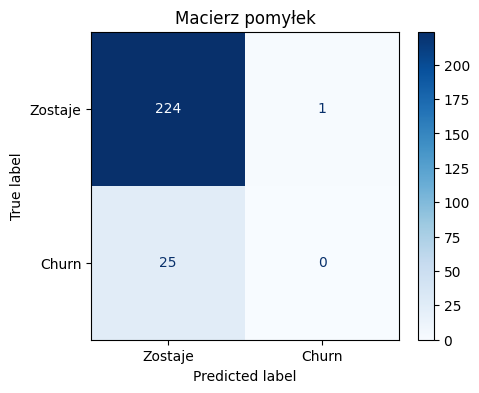

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Zostaje", "Churn"], ax=ax, cmap="Blues")
ax.set_title("Macierz pomyłek")
plt.show()

In [9]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}  (z przewidzianych churnów — ile faktycznie odeszło)")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}  (ze wszystkich, którzy odeszli — ilu model wykrył)")
print(f"F1:        {f1_score(y_test, y_pred):.3f}  (średnia harmoniczna precision/recall)")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.3f}  (jakość rankingu — niezależna od progu decyzyjnego 0.5)")

Accuracy:  0.896
Precision: 0.000  (z przewidzianych churnów — ile faktycznie odeszło)
Recall:    0.000  (ze wszystkich, którzy odeszli — ilu model wykrył)
F1:        0.000  (średnia harmoniczna precision/recall)
ROC-AUC:   0.761  (jakość rankingu — niezależna od progu decyzyjnego 0.5)


**To nie jest przykład wydumany na potrzeby notebooka — to dokładnie ten
wynik, który właśnie wyszedł powyżej.** Precision i recall = 0.000, mimo że
ROC-AUC = 0.76 (model realnie odróżnia klientów zagrożonych churnem — samo
rankingowanie działa nieźle). Powód: przy churn stanowiącym ~10% danych i
domyślnym progu decyzyjnym 0.5, `LogisticRegression` "opłaca się"
przewidywać wyłącznie klasę większościową — nigdy nie przekracza progu 0.5
dla klasy churn. To najczęstszy, realny efekt niezbalansowanych klas w
praktyce, nie tylko teoretyczne ostrzeżenie z podręcznika. Rozwiązania:
`class_weight="balanced"` (sekcja 8), obniżenie progu decyzyjnego poniżej
0.5, albo optymalizacja `GridSearchCV` bezpośrednio pod `scoring="f1"`
zamiast `"roc_auc"`.

### Który priorytet — precision czy recall — zależy od kosztu biznesowego błędu

- Jeśli akcja retencyjna (np. rabat) jest **tania**, a utrata klienta
  **droga** — priorytet ma `recall` (złap jak najwięcej faktycznych
  churnów, nawet kosztem kilku fałszywych alarmów).
- Jeśli akcja retencyjna jest **kosztowna** (np. osobisty kontakt
  handlowca) — priorytet ma `precision` (nie marnuj jej na klientów, którzy
  i tak by zostali).

To decyzja biznesowa, nie statystyczna — model dostarcza `predict_proba`,
próg 0.5 jest tylko domyślnym punktem odniesienia, nie prawem natury.

## 7. Walidacja krzyżowa — dlaczego jeden podział train/test to za mało

Wynik na pojedynczym podziale zależy częściowo od przypadku (który
dokładnie klient trafił do testu). Walidacja krzyżowa (k-fold) uśrednia
wynik po kilku różnych podziałach — daje bardziej wiarygodny obraz
stabilności modelu, nie tylko jedną liczbę.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # Stratified -> zachowuje proporcję klas w każdym foldzie

wyniki_cv = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"ROC-AUC w 5 foldach: {np.round(wyniki_cv, 3)}")
print(f"Średnia: {wyniki_cv.mean():.3f}  (+/- {wyniki_cv.std():.3f})")

ROC-AUC w 5 foldach: [0.852 0.777 0.715 0.789 0.716]
Średnia: 0.770  (+/- 0.051)


Ważne: `cross_val_score(model_pipeline, ...)` przekazuje CAŁY pipeline, nie
sam model — dzięki temu w każdym foldzie preprocessing (imputacja,
skalowanie, encoding) jest dopasowywany od nowa TYLKO na danych treningowych
tego konkretnego foldu. Gdybyś zrobił preprocessing raz na całym `X_train`
przed cross-walidacją, wystąpiłby dokładnie ten sam data leakage co w
sekcji 1, tylko w subtelniejszej formie (przeciek między foldami).

## 8. Strojenie hiperparametrów — `GridSearchCV` wewnątrz `Pipeline`

Nazwy parametrów do przeszukania budujesz z nazw kroków z `Pipeline`,
łącząc je podwójnym podkreślnikiem: `krok__parametr`. Dzięki temu
`GridSearchCV` strojąc model, cały czas trzyma się tej samej zasady —
preprocessing uczony od nowa w każdym foldzie, każdej kombinacji parametrów.

In [11]:
siatka_parametrow = {
    "model__C": [0.01, 0.1, 1, 10],              # 'model' = nazwa kroku w Pipeline, 'C' = parametr LogisticRegression
    "model__class_weight": [None, "balanced"],    # 'balanced' -> automatyczna korekta pod niezbalansowane klasy
}

grid_search = GridSearchCV(
    model_pipeline,
    param_grid=siatka_parametrow,   # WYMAGANE — słownik/lista słowników parametrów do przetestowania
    cv=cv,                           # opcjonalne, domyślnie 5-fold (bez stratyfikacji)
    scoring="roc_auc",               # opcjonalne, domyślnie .score() modelu (accuracy dla klasyfikatorów)
    n_jobs=-1,                       # opcjonalne — wykorzystaj wszystkie rdzenie
)

grid_search.fit(X_train, y_train)

print("Najlepsze parametry:", grid_search.best_params_)
print(f"Najlepszy ROC-AUC (CV): {grid_search.best_score_:.3f}")

Najlepsze parametry: {'model__C': 0.1, 'model__class_weight': None}
Najlepszy ROC-AUC (CV): 0.773


In [12]:
# finalna ocena NAJLEPSZEGO modelu na zbiorze testowym (którego GridSearchCV w ogóle nie widział)
najlepszy_model = grid_search.best_estimator_
y_pred_najlepszy = najlepszy_model.predict(X_test)
y_proba_najlepszy = najlepszy_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC na teście: {roc_auc_score(y_test, y_proba_najlepszy):.3f}")

ROC-AUC na teście: 0.760


Zwróć uwagę: `GridSearchCV` wybrał `class_weight=None`, mimo że
`"balanced"` był w siatce — bo optymalizował pod `scoring="roc_auc"`, a
ROC-AUC jest niezależne od progu decyzyjnego (patrz komentarz w sekcji 6),
więc `class_weight="balanced"` nie poprawia go bezpośrednio, choć
poprawiłoby `precision`/`recall` przy progu 0.5. To praktyczna lekcja:
**metryka podana w `scoring=` musi odpowiadać metryce, na której faktycznie
Ci zależy** — inaczej strojenie hiperparametrów zoptymalizuje coś innego,
niż myślisz.

## 9. Interpretacja modelu — skąd biorą się predykcje

Sam wynik metryki nie wystarcza biznesowo — warto umieć powiedzieć, KTÓRE
cechy najbardziej wpływają na przewidywany churn. Dla modelu liniowego
(`LogisticRegression`) to współczynniki; dla lasu losowego —
`feature_importances_`. Nazwy cech po `ColumnTransformer` (zwłaszcza po
one-hot encoding) trzeba wyciągnąć osobno — `get_feature_names_out()`.

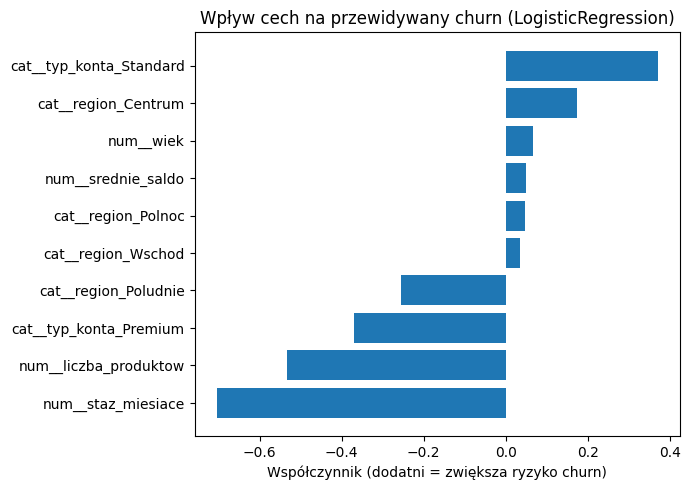

In [13]:
nazwy_cech = najlepszy_model.named_steps["preprocessing"].get_feature_names_out()
wspolczynniki = najlepszy_model.named_steps["model"].coef_[0]

df_wspolczynniki = (
    pd.DataFrame({"cecha": nazwy_cech, "wspolczynnik": wspolczynniki})
    .sort_values("wspolczynnik")
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(df_wspolczynniki["cecha"], df_wspolczynniki["wspolczynnik"])
ax.set_title("Wpływ cech na przewidywany churn (LogisticRegression)")
ax.set_xlabel("Współczynnik (dodatni = zwiększa ryzyko churn)")
plt.tight_layout()
plt.show()

Interpretacja współczynników regresji logistycznej: dodatni współczynnik =
cecha zwiększa log-szansę churnu, ujemny = zmniejsza. Ponieważ cechy
numeryczne były skalowane (`StandardScaler`), współczynniki są ze sobą
porównywalne (jednostka: odchylenia standardowe) — bez skalowania
porównywanie "która cecha ważniejsza" po samej wielkości współczynnika
byłoby mylące (cecha w tysiącach dominowałaby nad cechą 0-1 tylko przez
skalę, nie realny wpływ).

## 10. Model nieliniowy — `RandomForestClassifier` w tym samym Pipeline

Zaletą wzorca `Pipeline` jest to, że zmiana modelu to podmiana JEDNEGO
kroku — cały preprocessing zostaje identyczny, co daje uczciwe porównanie.

In [14]:
model_las = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced")),
])

wyniki_cv_las = cross_val_score(model_las, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"RandomForest ROC-AUC (CV): {wyniki_cv_las.mean():.3f} (+/- {wyniki_cv_las.std():.3f})")
print(f"LogisticRegression ROC-AUC (CV) dla porównania: {wyniki_cv.mean():.3f} (+/- {wyniki_cv.std():.3f})")

RandomForest ROC-AUC (CV): 0.718 (+/- 0.057)
LogisticRegression ROC-AUC (CV) dla porównania: 0.770 (+/- 0.051)


Przy tak prostym, w większości liniowym mechanizmie generowania `churn` w
naszych danych syntetycznych regresja logistyczna zwykle wypada
porównywalnie albo lepiej niż las losowy — co samo w sobie jest ważną
lekcją: **bardziej złożony model nie zawsze oznacza lepszy wynik**,
szczególnie gdy prawdziwa zależność w danych jest w większości liniowa.
Warto zawsze mieć prosty model liniowy jako punkt odniesienia (baseline),
zanim sięgnie się po coś bardziej złożonego.

## 11. Zapis wytrenowanego Pipeline do wdrożenia

Cały `Pipeline` (preprocessing + model) zapisuje się jednym plikiem —
wdrożenie (np. task w Airflow, API) wczytuje go i od razu wywołuje
`.predict()` na surowych, nieprzetworzonych danych wejściowych.

In [15]:
import joblib

joblib.dump(najlepszy_model, "model_churn.joblib")

# wczytanie i użycie — dokładnie tak wyglądałby kod w skrypcie produkcyjnym/tasku Airflow
model_wczytany = joblib.load("model_churn.joblib")
nowy_klient = X_test.iloc[[0]]   # pojedynczy wiersz, surowe dane — bez ręcznego preprocessing
print("Prawdopodobieństwo churn:", model_wczytany.predict_proba(nowy_klient)[0, 1].round(3))

Prawdopodobieństwo churn: 0.062


## Podsumowanie

- **`Pipeline` nie jest wygodą składniową** — to mechanizm, który
  strukturalnie uniemożliwia najczęstszy błąd (data leakage przez
  preprocessing dopasowany do zbioru testowego/foldów walidacyjnych).
- **`ColumnTransformer`** rozdziela przygotowanie cech numerycznych i
  kategorycznych — imputacja medianą/najczęstszą wartością, skalowanie,
  one-hot encoding.
- **Cross-validation** zawsze na całym `Pipeline`, nigdy na samym modelu po
  ręcznym preprocessingu na całym zbiorze.
- **`GridSearchCV`** stroi hiperparametry przez `krok__parametr`, trzymając
  się tej samej zasady co zwykły `fit`.
- **Metryka dopasowana do problemu biznesowego** — `accuracy` prawie nigdy
  nie wystarcza przy niezbalansowanych klasach; wybór między precision a
  recall to decyzja o koszcie błędu, nie czysto statystyczna.
- **Baseline** (prosty model liniowy) zawsze przed sięgnięciem po coś
  bardziej złożonego — złożoność ma sens tylko, gdy realnie poprawia wynik.
- Zapisany `Pipeline` (`joblib`) to gotowy artefakt do wdrożenia — bez
  ręcznego odtwarzania kroków preprocessingu w kodzie produkcyjnym.